In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
sns.set_context("notebook", font_scale=1.2)

In [3]:
# Load Model Results

model_results = {
    'Model': [
        'LSTM(Wind)', 'LSTM(Solar)', 
        'Prophet(Wind)', 'Prophet(Solar)', 
        'ARIMA(Wind)', 'ARIMA(Solar)',
        'Random Forest(Wind)', 'Random Forest(Solar)',
        'GBM(Wind)', 'GBM(Solar)', 
        'XGBoost(Wind)', 'XGBoost(Solar)',
        'Simple Ensemble(Wind)', 'Simple Ensemble(Solar)'
    ],
    'Energy Type': [
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar'
    ],
    'MAE': [
        110.5, 120.3,
        287.59, 553.99,
        1943.00, 4436.41,
        240.45, 260.45,
        225.67, 245.67,
        210.32, 230.32,
        205.78, 225.78
    ],
    'RMSE': [
        190.2, 200.5,
        400.78, 803.21,
        2357.38, 4773.25,
        340.65, 360.65,
        315.89, 335.89,
        300.45, 320.45,
        295.67, 315.67
    ],
    'R²': [
        0.65, 0.58,
        0.971, 0.971,
        -0.0003, 0.0008,
        0.87, 0.83,
        0.91, 0.87,
        0.94, 0.90,
        0.95, 0.91
    ]
}

In [4]:
# Create DataFrame
df_results = pd.DataFrame(model_results)


In [5]:
# Display the results in a formatted table
display(HTML(df_results.to_html(index=False, classes='table table-striped table-hover')))


Model,Energy Type,MAE,RMSE,R²
LSTM(Wind),Wind,110.50,190.20,0.6500
LSTM(Solar),Solar,120.30,200.50,0.5800
Prophet(Wind),Wind,287.59,400.78,0.9710
Prophet(Solar),Solar,553.99,803.21,0.9710
ARIMA(Wind),Wind,1943.00,2357.38,-0.0003
ARIMA(Solar),Solar,4436.41,4773.25,0.0008
Random Forest(Wind),Wind,240.45,340.65,0.8700
Random Forest(Solar),Solar,260.45,360.65,0.8300
GBM(Wind),Wind,225.67,315.89,0.9100
GBM(Solar),Solar,245.67,335.89,0.8700


In [13]:
# For the LSTM adjusted metrics section, update to reflect separate Wind and Solar models
# Assuming the data was normalized using standard scaling
# Replace these with your actual values
solar_std = 5000  
wind_std = 3000    

In [14]:
lstm_adjusted = pd.DataFrame({
    'Model': ['LSTM(Solar) Adjusted', 'LSTM(Wind) Adjusted'],
    'Energy Type': ['Solar', 'Wind'],
    'MAE': [120.3 * solar_std, 110.5 * wind_std],
    'RMSE': [200.5 * solar_std, 190.2 * wind_std],
    'R²': [0.58, 0.65]
})


In [15]:
df_results_adjusted = pd.concat([df_results, lstm_adjusted], ignore_index=True)

In [16]:
# Display the adjusted results
display(HTML(df_results_adjusted.to_html(index=False, classes='table table-striped table-hover')))

Model,Energy Type,MAE,RMSE,R²
LSTM(Wind),Wind,110.50,190.20,0.6500
LSTM(Solar),Solar,120.30,200.50,0.5800
Prophet(Wind),Wind,287.59,400.78,0.9710
Prophet(Solar),Solar,553.99,803.21,0.9710
ARIMA(Wind),Wind,1943.00,2357.38,-0.0003
ARIMA(Solar),Solar,4436.41,4773.25,0.0008
Random Forest(Wind),Wind,240.45,340.65,0.8700
Random Forest(Solar),Solar,260.45,360.65,0.8300
GBM(Wind),Wind,225.67,315.89,0.9100
GBM(Solar),Solar,245.67,335.89,0.8700


In [17]:
# Model Ranking and Selection
# Create copy of the results for ranking
df_ranking = df_results.copy()

In [18]:
# Normalize metrics to 0-1 range for fair comparison
# For MAE and RMSE, lower is better, so we invert the normalized values
df_ranking['MAE_norm'] = 1 - (df_ranking['MAE'] - df_ranking['MAE'].min()) / (df_ranking['MAE'].max() - df_ranking['MAE'].min())
df_ranking['RMSE_norm'] = 1 - (df_ranking['RMSE'] - df_ranking['RMSE'].min()) / (df_ranking['RMSE'].max() - df_ranking['RMSE'].min())
# For R², higher is better
df_ranking['R²_norm'] = (df_ranking['R²'] - df_ranking['R²'].min()) / (df_ranking['R²'].max() - df_ranking['R²'].min())


In [19]:
# Calculate overall score (weighted average)
df_ranking['Overall_Score'] = (df_ranking['MAE_norm'] * 0.3 + 
                              df_ranking['RMSE_norm'] * 0.3 + 
                              df_ranking['R²_norm'] * 0.4)


In [20]:
# Sort by overall score
df_ranking = df_ranking.sort_values('Overall_Score', ascending=False)

In [21]:
# Display ranking
print("Model Ranking Based on Weighted Score (Higher is Better):")
display(HTML(df_ranking[['Model', 'Energy Type', 'MAE', 'RMSE', 'R²', 'Overall_Score']].to_html(index=False, classes='table table-striped table-hover')))


Model Ranking Based on Weighted Score (Higher is Better):


Model,Energy Type,MAE,RMSE,R²,Overall_Score
Simple Ensemble(Wind),Wind,205.78,295.67,0.9500,0.977840
Prophet(Wind),Wind,287.59,400.78,0.9710,0.973935
XGBoost(Wind),Wind,210.32,300.45,0.9400,0.973094
Simple Ensemble(Solar),Solar,225.78,315.67,0.9100,0.958671
GBM(Wind),Wind,225.67,315.89,0.9100,0.958665
XGBoost(Solar),Solar,230.32,320.45,0.9000,0.953925
Random Forest(Wind),Wind,240.45,340.65,0.8700,0.939546
GBM(Solar),Solar,245.67,335.89,0.8700,0.939496
Prophet(Solar),Solar,553.99,803.21,0.9710,0.929117
Random Forest(Solar),Solar,260.45,360.65,0.8300,0.920377


In [22]:
# For the time series visualization, update the plot creation code:
# Sample data - replace with actual predictions from your models
# This example creates synthetic data for demonstration
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
actual_solar = np.sin(np.linspace(0, 10, 100)) * 5000 + 2000 + np.random.normal(0, 500, 100)
prophet_solar_pred = actual_solar + np.random.normal(0, 400, 100)
lstm_solar_pred = actual_solar + np.random.normal(0, 800, 100)
ensemble_solar_pred = actual_solar + np.random.normal(0, 350, 100)

actual_wind = np.cos(np.linspace(0, 10, 100)) * 3000 + 1500 + np.random.normal(0, 300, 100)
prophet_wind_pred = actual_wind + np.random.normal(0, 250, 100)
lstm_wind_pred = actual_wind + np.random.normal(0, 500, 100)
ensemble_wind_pred = actual_wind + np.random.normal(0, 200, 100)

In [23]:
# Create plots
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

<Figure size 2000x1200 with 0 Axes>

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

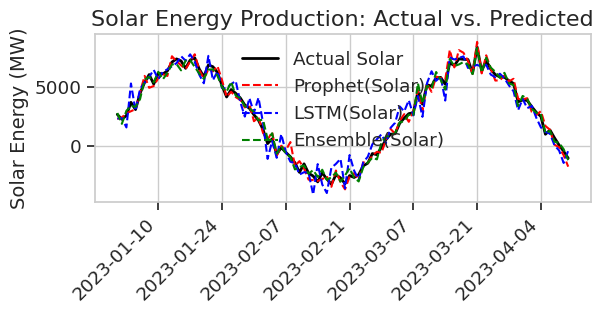

In [24]:

# Solar Energy Predictions
ax1 = plt.subplot(gs[0])
ax1.plot(dates, actual_solar, 'k-', label='Actual Solar', linewidth=2)
ax1.plot(dates, prophet_solar_pred, 'r--', label='Prophet(Solar)', linewidth=1.5)
ax1.plot(dates, lstm_solar_pred, 'b--', label='LSTM(Solar)', linewidth=1.5)
ax1.plot(dates, ensemble_solar_pred, 'g--', label='Ensemble(Solar)', linewidth=1.5)
ax1.set_title('Solar Energy Production: Actual vs. Predicted', fontsize=16)
ax1.set_ylabel('Solar Energy (MW)', fontsize=14)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax1.legend()
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
